In [1]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from pso import pso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from keras.models import Sequential
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from keras.layers import Dense

In [3]:
data = pd.read_excel('./data/data.xlsx')

# 提取输入特征和输出标签
X = data[['外侧干球','压缩机频率','风机频率','冷媒压力2#排气','冷媒压力3#喷焓','冷媒压力4#回气','T3','冷中','辅进','冷媒散热管出口','辅出']]
Y = data[['能力','能效','热回流率']]
# 数据标准化
scaler = StandardScaler()
x = scaler.fit_transform(X)
y = scaler.fit_transform(Y)
# 划分数据集为训练集、验证集和测试集
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [4]:
ylen = 7
# 定义神经网络模型
def create_model(params):
    model = Sequential()
    model.add(Dense(units=ylen, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(units=y_train.shape[1]))
    
    # 设置权重和阈值
    model.layers[0].set_weights([params[:ylen*X_train.shape[1]].reshape((X_train.shape[1], ylen)), params[ylen*X_train.shape[1]:ylen*X_train.shape[1]+ylen]])
    model.layers[1].set_weights([params[ylen*X_train.shape[1]+ylen:ylen*X_train.shape[1]+ylen+ylen*y_train.shape[1]].reshape((ylen, y_train.shape[1])), params[ylen*X_train.shape[1]+ylen+ylen*y_train.shape[1]:]])

    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    return model

In [5]:
# 定义PSO优化的目标函数
def objective_function(params):
    model = create_model(params)
#    loss, _ = model.evaluate(X_train, y_train, verbose=0)
    history = model.fit(X_train, y_train, epochs=300, batch_size=32,verbose=0)
#    loss, _ = model.evaluate(X_test, y_test, verbose=0)
    return history.history['loss'][-1]

In [6]:
length = X_train.shape[1]*ylen+ylen+ylen*y_train.shape[1]+y_train.shape[1]

In [7]:
# 设置PSO参数
lb = [-1] * length  # 权重和阈值的下限
ub = [1] * length   # 权重和阈值的上限

In [8]:
# 进行PSO优化
best_params, _, pso_loss = pso(objective_function, lb, ub, swarmsize=30, maxiter=50)





1
0.023063289001584053
2
0.021493641659617424
3
0.019743358716368675
4
0.019743358716368675
5
0.019743358716368675
6
0.019743358716368675
7
0.019743358716368675
8
0.01973695680499077
9
0.01973695680499077
10
0.019720876589417458
11
0.019720876589417458
12
0.01964537613093853
13
0.01964537613093853
14
0.01964537613093853
15
0.01964537613093853
16
0.01964537613093853
17
0.01964537613093853
18
0.018794678151607513
19
0.018794678151607513
20
0.018794678151607513
21
0.018794678151607513
22
0.018794678151607513
23
0.018787920475006104
24
0.018787920475006104
25
0.018787920475006104
26
0.018787920475006104
27
0.018572667613625526
28
0.018572667613625526
29
0.018507909029722214
30
0.018507909029722214
31
0.018507909029722214
32
0.018507909029722214
33
0.018507909029722214
34
0.018507909029722214
35
0.018507909029722214
36
0.018507909029722214
37
0.018507909029722214
38
0.018507909029722214
39
0.018507909029722214
40
0.018488135188817978
41
0.018488135188817978
42
0.018488135188817978
43
0.

In [9]:

# 使用最优参数构建最终的神经网络模型
best_model = create_model(best_params)

In [10]:
best_model.fit(X_train, y_train, epochs=300, batch_size=32)

Epoch 1/300
33/33 [==============================] - 1s 2ms/step - loss: 0.7768 - accuracy: 0.5885
Epoch 2/300
33/33 [==============================] - 0s 2ms/step - loss: 0.6082 - accuracy: 0.6423
Epoch 3/300
33/33 [==============================] - 0s 1ms/step - loss: 0.5297 - accuracy: 0.6635
Epoch 4/300
33/33 [==============================] - 0s 2ms/step - loss: 0.4833 - accuracy: 0.6702
Epoch 5/300
33/33 [==============================] - 0s 2ms/step - loss: 0.4521 - accuracy: 0.6731
Epoch 6/300
33/33 [==============================] - 0s 2ms/step - loss: 0.4273 - accuracy: 0.6750
Epoch 7/300
33/33 [==============================] - 0s 2ms/step - loss: 0.4055 - accuracy: 0.7067
Epoch 8/300
33/33 [==============================] - 0s 2ms/step - loss: 0.3846 - accuracy: 0.7317
Epoch 9/300
33/33 [==============================] - 0s 2ms/step - loss: 0.3641 - accuracy: 0.7385
Epoch 10/300
33/33 [==============================] - 0s 2ms/step - loss: 0.3440 - accuracy: 0.7385
Epoch 11/

33/33 [==============================] - 0s 1ms/step - loss: 0.0471 - accuracy: 0.9462
Epoch 84/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0464 - accuracy: 0.9442
Epoch 85/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0460 - accuracy: 0.9500
Epoch 86/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0454 - accuracy: 0.9471
Epoch 87/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0448 - accuracy: 0.9471
Epoch 88/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0446 - accuracy: 0.9500
Epoch 89/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0442 - accuracy: 0.9510
Epoch 90/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0436 - accuracy: 0.9452
Epoch 91/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0427 - accuracy: 0.9510
Epoch 92/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0426 - accuracy: 0.9462
Epoch 93/300


33/33 [==============================] - 0s 2ms/step - loss: 0.0252 - accuracy: 0.9673
Epoch 165/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0252 - accuracy: 0.9692
Epoch 166/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0250 - accuracy: 0.9702
Epoch 167/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0251 - accuracy: 0.9683
Epoch 168/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0251 - accuracy: 0.9702
Epoch 169/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0248 - accuracy: 0.9692
Epoch 170/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0248 - accuracy: 0.9692
Epoch 171/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0246 - accuracy: 0.9702
Epoch 172/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0245 - accuracy: 0.9692
Epoch 173/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0245 - accuracy: 0.9683
Epoc

33/33 [==============================] - 0s 2ms/step - loss: 0.0202 - accuracy: 0.9721
Epoch 246/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0201 - accuracy: 0.9721
Epoch 247/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0201 - accuracy: 0.9769
Epoch 248/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0200 - accuracy: 0.9750
Epoch 249/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0198 - accuracy: 0.9740
Epoch 250/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0199 - accuracy: 0.9740
Epoch 251/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0198 - accuracy: 0.9760
Epoch 252/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0199 - accuracy: 0.9702
Epoch 253/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0198 - accuracy: 0.9760
Epoch 254/300
33/33 [==============================] - 0s 2ms/step - loss: 0.0198 - accuracy: 0.9760
Epoc

In [11]:
# 使用模型进行预测
prediction = best_model.predict(X_test)

# 如果需要，将预测结果反标准化回原始范围
predictions = scaler.inverse_transform(prediction)

9/9 [==============================] - 1s 50ms/step


In [12]:
def r_squared(y_true, y_pred):

    # 计算总平方和（Total Sum of Squares）
    total_sum_of_squares = np.sum((y_true - np.mean(y_true))**2)

    # 计算残差平方和（Residual Sum of Squares）
    residual_sum_of_squares = np.sum((y_true - y_pred)**2)

    # 计算R-squared（决定系数）
    r2 = 1 - (residual_sum_of_squares / total_sum_of_squares)

    return r2


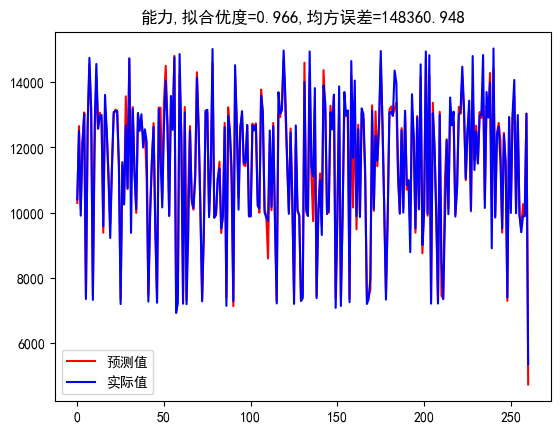

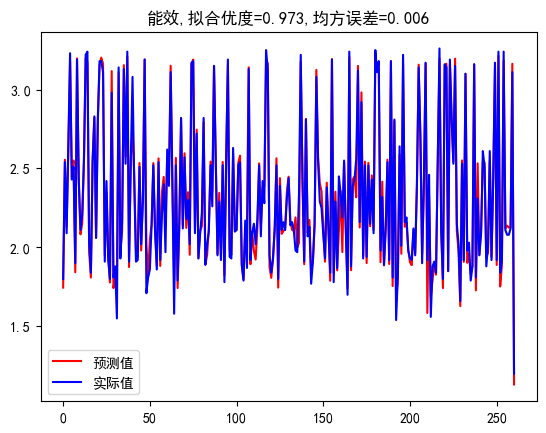

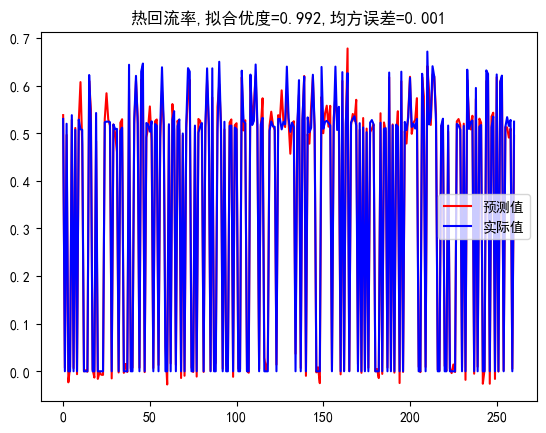

In [13]:
#预测数据索引
index=0
xarry=np.arange(predictions.shape[0])
plt.rcParams['font.family'] = ['SimHei']
plt.plot(xarry,predictions[:,index],label='预测值',c='r')
#恢复测试数据集
Y_data=scaler.inverse_transform(y_test)
r2=r_squared(predictions[:,index],Y_data[:,index])
plt.plot(xarry,Y_data[:,index],label="实际值",c='b')
mse = mean_squared_error(predictions[:,index], Y_data[:,index])
plt.title(Y.columns[index]+',拟合优度={:.3f}'.format(r2)+',均方误差={:.3f}'.format(mse))
plt.legend()
plt.show()

#预测数据索引
index=1
xarry=np.arange(predictions.shape[0])
plt.rcParams['font.family'] = ['SimHei']
plt.plot(xarry,predictions[:,index],label='预测值',c='r')
#恢复测试数据集
Y_data=scaler.inverse_transform(y_test)
r2=r_squared(predictions[:,index],Y_data[:,index])
plt.plot(xarry,Y_data[:,index],label="实际值",c='b')
mse = mean_squared_error(predictions[:,index], Y_data[:,index])
plt.title(Y.columns[index]+',拟合优度={:.3f}'.format(r2)+',均方误差={:.3f}'.format(mse))
plt.legend()
plt.show()

#预测数据索引
index=2
xarry=np.arange(predictions.shape[0])
plt.rcParams['font.family'] = ['SimHei']
plt.plot(xarry,predictions[:,index],label='预测值',c='r')
#恢复测试数据集
Y_data=scaler.inverse_transform(y_test)
r2=r_squared(predictions[:,index],Y_data[:,index])
plt.plot(xarry,Y_data[:,index],label="实际值",c='b')
mse = mean_squared_error(predictions[:,index], Y_data[:,index])
plt.title(Y.columns[index]+',拟合优度={:.3f}'.format(r2)+',均方误差={:.3f}'.format(mse))
plt.legend()
plt.show()